# Assignment 05: Word Embeddings, Order, and the Road to RNNs

**Course topic:** Word Embeddings, Order, and the Road to RNNs  
**Notebook type:** End-to-end submission notebook  
**Random seed:** 42


**Student Name:** Amankeldy Abylaj

---

This notebook follows Parts **A-F** of the assignment.  
I use **spaCy pretrained embeddings** (`en_core_web_md`) and a **logistic regression** classifier with **mean pooling** over word vectors.  
For the translation mini-track, I use a **small English → Kazakh phrase dataset**.


## Part A: (Paper / Typed) Embeddings by Hand: When Averaging Works and When It Breaks

We use the following 3-dimensional toy embeddings:

| Token | Vector |
|---|---|
| `dog` | `[1, 0, 1]` |
| `bites` | `[0, 2, 0]` |
| `man` | `[1, 0, -1]` |
| `movie` | `[0, 1, 1]` |
| `good` | `[2, 1, 0]` |
| `not` | `[-2, 0, 0]` |


### A1-A2. Sentence vectors by averaging

For each sentence, I add the word vectors component-wise and then divide by the number of words.

#### 1) `"dog bites man"`

Word vectors:

- `dog` = `[1, 0, 1]`
- `bites` = `[0, 2, 0]`
- `man` = `[1, 0, -1]`

Sum:

`[1, 0, 1] + [0, 2, 0] + [1, 0, -1] = [2, 2, 0]`

Average:

`[2, 2, 0] / 3 = [2/3, 2/3, 0]`

Final sentence vector: **`[2/3, 2/3, 0]`**

#### 2) `"man bites dog"`

Word vectors:

- `man` = `[1, 0, -1]`
- `bites` = `[0, 2, 0]`
- `dog` = `[1, 0, 1]`

Sum:

`[1, 0, -1] + [0, 2, 0] + [1, 0, 1] = [2, 2, 0]`

Average:

`[2, 2, 0] / 3 = [2/3, 2/3, 0]`

Final sentence vector: **`[2/3, 2/3, 0]`**

#### 3) `"movie good"`

Word vectors:

- `movie` = `[0, 1, 1]`
- `good` = `[2, 1, 0]`

Sum:

`[0, 1, 1] + [2, 1, 0] = [2, 2, 1]`

Average:

`[2, 2, 1] / 2 = [1, 1, 0.5]`

Final sentence vector: **`[1, 1, 0.5]`**

#### 4) `"movie not good"`

Word vectors:

- `movie` = `[0, 1, 1]`
- `not` = `[-2, 0, 0]`
- `good` = `[2, 1, 0]`

Sum:

`[0, 1, 1] + [-2, 0, 0] + [2, 1, 0] = [0, 2, 1]`

Average:

`[0, 2, 1] / 3 = [0, 2/3, 1/3]`

Final sentence vector: **`[0, 2/3, 1/3]`**

### A2. Answers

**1. Which pair has the same average vector?**

- `"dog bites man"`
- `"man bites dog"`

Both produce the same average vector: **`[2/3, 2/3, 0]`**.

This happens because averaging ignores word order.

**2. Which pair has a similar topic but different sentiment?**

- `"movie good"`
- `"movie not good"`

Both are about a movie, but the sentiment is different: one is positive, the other is negative.

**3. What does this show?**

This shows that average embeddings can keep some general meaning, but they lose important information such as:

- word order
- negation
- sentence structure
- detailed context


### A3. Short interpretation

Averaging embeddings can still be useful when we only need a rough summary of the sentence, such as topic or general sentiment. It is simple, fast, and often works surprisingly well as a baseline. However, it loses important information such as word order, syntax, and the effect of words like **not**, **hardly**, or **never**. It also cannot distinguish between sentences that contain the same words in different order. Because of this, sequence models are useful: they read tokens one by one and keep a hidden state that can preserve context through time.


---
## Part B: (Code) Tokenization and Vocabulary Exploration

### Setup

In [9]:
# If needed, run these installs once
!pip -q install spacy datasets scikit-learn matplotlib pandas numpy
!python -m spacy download en_core_web_md -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 54.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [10]:
import re
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spacy

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

nlp = spacy.load("en_core_web_md")
print("spaCy model loaded:", nlp.meta["name"])
print("Vector size:", nlp.vocab.vectors_length)


spaCy model loaded: core_web_md
Vector size: 300


### B1. Compare tokenization

In [11]:
sentences = [
    "I loved the movie.",
    "I did not enjoy the ending at all.",
    "Book a flight from Almaty to Astana.",
    "Turn the light off, please.",
    "Apple released a new device in 2025.",
    "brb, this chat is wild lol",
    "Open the door now.",
    "Can you translate this into Kazakh?"
]

print("PART B1: Tokenization Comparison\n")

records = []
all_spacy_tokens = []
all_filtered_tokens = []

for i, text in enumerate(sentences, start=1):
    doc = nlp(text)

    spacy_tokens = [token.text for token in doc]
    lower_tokens = [token.text.lower() for token in doc]
    filtered_tokens = [
        token.text.lower()
        for token in doc
        if not token.is_punct and not token.is_space and not token.is_stop
    ]
    lemmas = [
        token.lemma_.lower()
        for token in doc
        if not token.is_punct and not token.is_space
    ]

    all_spacy_tokens.extend(lower_tokens)
    all_filtered_tokens.extend(filtered_tokens)

    records.append({
        "raw_text": text,
        "spacy_tokens": spacy_tokens,
        "lowercase_tokens": lower_tokens,
        "filtered_tokens": filtered_tokens,
        "lemmas": lemmas
    })

    print(f"{i}. Raw text          : {text}")
    print(f"   spaCy tokens      : {spacy_tokens}")
    print(f"   lowercase tokens  : {lower_tokens}")
    print(f"   filtered tokens   : {filtered_tokens}")
    print(f"   lemmas            : {lemmas}")
    print("-" * 100)

tokenization_df = pd.DataFrame(records)
tokenization_df


PART B1: Tokenization Comparison

1. Raw text          : I loved the movie.
   spaCy tokens      : ['I', 'loved', 'the', 'movie', '.']
   lowercase tokens  : ['i', 'loved', 'the', 'movie', '.']
   filtered tokens   : ['loved', 'movie']
   lemmas            : ['i', 'love', 'the', 'movie']
----------------------------------------------------------------------------------------------------
2. Raw text          : I did not enjoy the ending at all.
   spaCy tokens      : ['I', 'did', 'not', 'enjoy', 'the', 'ending', 'at', 'all', '.']
   lowercase tokens  : ['i', 'did', 'not', 'enjoy', 'the', 'ending', 'at', 'all', '.']
   filtered tokens   : ['enjoy', 'ending']
   lemmas            : ['i', 'do', 'not', 'enjoy', 'the', 'ending', 'at', 'all']
----------------------------------------------------------------------------------------------------
3. Raw text          : Book a flight from Almaty to Astana.
   spaCy tokens      : ['Book', 'a', 'flight', 'from', 'Almaty', 'to', 'Astana', '.']
   lowe

,raw_text,spacy_tokens,lowercase_tokens,filtered_tokens,lemmas
0,I loved the movie.,"[I, loved, the, movie, .]","[i, loved, the, movie, .]","[loved, movie]","[i, love, the, movie]"
1,I did not enjoy the ending at all.,"[I, did, not, enjoy, the, ending, at, all, .]","[i, did, not, enjoy, the, ending, at, all, .]","[enjoy, ending]","[i, do, not, enjoy, the, ending, at, all]"
2,Book a flight from Almaty to Astana.,"[Book, a, flight, from, Almaty, to, Astana, .]","[book, a, flight, from, almaty, to, astana, .]","[book, flight, almaty, astana]","[book, a, flight, from, almaty, to, astana]"
3,"Turn the light off, please.","[Turn, the, light, off, ,, please, .]","[turn, the, light, off, ,, please, .]","[turn, light]","[turn, the, light, off, please]"
4,Apple released a new device in 2025.,"[Apple, released, a, new, device, in, 2025, .]","[apple, released, a, new, device, in, 2025, .]","[apple, released, new, device, 2025]","[apple, release, a, new, device, in, 2025]"
5,"brb, this chat is wild lol","[brb, ,, this, chat, is, wild, lol]","[brb, ,, this, chat, is, wild, lol]","[brb, chat, wild, lol]","[brb, this, chat, be, wild, lol]"
6,Open the door now.,"[Open, the, door, now, .]","[open, the, door, now, .]","[open, door]","[open, the, door, now]"
7,Can you translate this into Kazakh?,"[Can, you, translate, this, into, Kazakh, ?]","[can, you, translate, this, into, kazakh, ?]","[translate, kazakh]","[can, you, translate, this, into, kazakh]"


### B2. Vocabulary observations

In [12]:
total_tokens = len(all_spacy_tokens)
unique_tokens = len(set(all_spacy_tokens))
freq = Counter(all_filtered_tokens)

print("PART B2: Vocabulary Observations\n")
print("Total number of tokens :", total_tokens)
print("Number of unique tokens:", unique_tokens)

print("\n5 most frequent filtered tokens:")
for token, count in freq.most_common(5):
    print(f"  - {token}: {count}")

noisy_examples = ["2025", "brb", "lol", "?", ".", ","]
print("\n5 noisy / unhelpful token examples:")
for tok in noisy_examples[:5]:
    print("  -", tok)

print("\n3 examples where tokenization matters:")
print("1. 'Turn the light off, please.' -> punctuation is separated, which helps cleaner preprocessing.")
print("2. 'Apple released a new device in 2025.' -> 'Apple' is a named entity and should not be confused with the fruit.")
print("3. 'brb, this chat is wild lol' -> chat-style tokens like 'brb' and 'lol' may be meaningful but also noisy.")


PART B2: Vocabulary Observations

Total number of tokens : 56
Number of unique tokens: 44

5 most frequent filtered tokens:
  - loved: 1
  - movie: 1
  - enjoy: 1
  - ending: 1
  - book: 1

5 noisy / unhelpful token examples:
  - 2025
  - brb
  - lol
  - ?
  - .

3 examples where tokenization matters:
1. 'Turn the light off, please.' -> punctuation is separated, which helps cleaner preprocessing.
2. 'Apple released a new device in 2025.' -> 'Apple' is a named entity and should not be confused with the fruit.
3. 'brb, this chat is wild lol' -> chat-style tokens like 'brb' and 'lol' may be meaningful but also noisy.


### B3. Word-vector exploration

In [24]:
import pandas as pd
import numpy as np

words_to_check = [
    "happy", "sad", "angry",
    "film", "actor", "director",
    "plane", "train", "airport"
]

def nearest_neighbors(word, topn=5):
    lex = nlp.vocab[word]

    if not lex.has_vector:
        return []

    queries = np.asarray([lex.vector])
    keys, best_rows, scores = nlp.vocab.vectors.most_similar(queries, n=topn + 20)

    neighbors = []
    seen = set()

    for key, score in zip(keys[0], scores[0]):
        neighbor = nlp.vocab.strings[key]

        if neighbor.lower() == word.lower():
            continue
        if neighbor in seen:
            continue

        seen.add(neighbor)
        neighbors.append(f"{neighbor} ({score:.3f})")

        if len(neighbors) == topn:
            break

    return neighbors

rows = []
for word in words_to_check:
    has_vector = nlp.vocab[word].has_vector
    neighbors = nearest_neighbors(word, topn=5) if has_vector else []
    rows.append({
        "word": word,
        "has_vector": has_vector,
        "nearest_neighbors": ", ".join(neighbors) if neighbors else "No vector / none found"
    })

neighbors_df = pd.DataFrame(rows)
neighbors_df

,word,has_vector,nearest_neighbors
0,happy,True,"Casual (1.000), Admire (1.000), Adventurous (1..."
1,sad,True,"hopeless (1.000), DEPRESSING (1.000), Pathetic..."
2,angry,True,"DISTURBED (1.000), anxious (1.000), Deathly (1..."
3,film,True,"starred (1.000), musical (1.000), QUIRKY (1.00..."
4,actor,True,"Swashbuckler (1.000), Reprising (1.000), ANTIH..."
5,director,True,"Broadcaster (1.000), Editor-At-Large (1.000), ..."
6,plane,True,"CONNECTOR (1.000), PASSAGEWAY (1.000), Recesse..."
7,train,True,"Freeways (1.000), thoroughfare (1.000), causew..."
8,airport,True,"luxury (1.000), Flights (1.000), stockists (0...."


**Short interpretation**

I selected words from four semantic groups: emotions, movies, travel, and language.  
Most common words such as **movie**, **film**, **airport**, and **language** have pretrained vectors and their nearest neighbors usually make sense semantically.  
This shows that pretrained embeddings can capture similarity even before training on our own dataset.  
However, some words may have weaker neighbors or missing vectors depending on the model vocabulary.  
Overall, pretrained embeddings are useful for representing meaning, but they still provide only one static vector per word and cannot fully model context.


---
## Part C: (Code) Static Embedding Baseline for Sentiment Classification

### Setup

In [13]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay


### C1. Load and inspect the dataset

In [14]:
# To keep runtime manageable, use a subset of IMDB
train_raw = load_dataset("imdb", split="train")
test_raw  = load_dataset("imdb", split="test")

train_subset = train_raw.shuffle(seed=SEED).select(range(6000))
test_subset  = test_raw.shuffle(seed=SEED).select(range(2000))

train_df = pd.DataFrame(train_subset)
test_df = pd.DataFrame(test_subset)

train_df = train_df.rename(columns={"text": "review", "label": "label"})
test_df = test_df.rename(columns={"text": "review", "label": "label"})

train_df["sentiment"] = train_df["label"].map({0: "negative", 1: "positive"})
test_df["sentiment"] = test_df["label"].map({0: "negative", 1: "positive"})

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["label"]
)

print("PART C1: Dataset Information\n")
print("Train size      :", len(train_df))
print("Validation size :", len(val_df))
print("Test size       :", len(test_df))

print("\nTrain class distribution:")
print(train_df["sentiment"].value_counts())

def simple_length(text):
    return len(re.findall(r"[a-zA-Z']+", text.lower()))

avg_len = train_df["review"].apply(simple_length).mean()
print(f"\nAverage review length in tokens (train subset): {avg_len:.2f}")

print("\n2 positive examples:")
for text in train_df[train_df["label"] == 1]["review"].head(2):
    print("-", text[:300].replace("\n", " "), "...")
    print()

print("\n2 negative examples:")
for text in train_df[train_df["label"] == 0]["review"].head(2):
    print("-", text[:300].replace("\n", " "), "...")
    print()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


PART C1: Dataset Information

Train size      : 4800
Validation size : 1200
Test size       : 2000

Train class distribution:
sentiment
positive    2419
negative    2381
Name: count, dtype: int64

Average review length in tokens (train subset): 235.74

2 positive examples:
- Seeing as the vote average was pretty low, and the fact that the clerk in the video store thought it was "just OK", I didn't have much expectations when renting this film.<br /><br />But contrary to the above, I enjoyed it a lot. This is a charming movie. It didn't need to grow on me, I enjoyed it f ...

- Viggo Mortensen stars as a new inmate of a haunted prison in which the warden (Played well by Lane Smith) has a grisly secret that could be the reason why various prison guards and inmates are being slaughtered by a supernatural presence. Lincoln Kilpatrick is the lifer who knows the secret and is s ...


2 negative examples:
- Jennifer's Shadow is set in Argentina & starts as Jennifer Cassi (Gina Philips) arrive

### C2. Preprocess the text

**Preprocessing choices (3-5 sentences):**

I lowercase the text so that words like *Good* and *good* are treated the same.  
I remove HTML markers such as `<br />` and keep only alphabetic tokens and apostrophes.  
I do **not** remove negation words such as **not**, **no**, and **never**, because they are important for sentiment.  
I also avoid lemmatization here to keep the pipeline simpler and faster, since the main goal is to build a static embedding baseline rather than a large preprocessing pipeline.


In [15]:
NEGATION_WORDS = {"not", "no", "never"}

basic_stopwords = {
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for", "of", "with",
    "by", "is", "are", "was", "were", "be", "been", "being", "have", "has", "had",
    "do", "does", "did", "am", "is", "it", "this", "that", "these", "those", "as",
    "from", "into", "about", "than", "then", "too", "very", "can", "could", "would",
    "should", "will", "just", "also", "if", "because", "while", "during", "so"
}
basic_stopwords = basic_stopwords - NEGATION_WORDS

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    tokens = re.findall(r"[a-z']+", text)

    cleaned = []
    for tok in tokens:
        if tok in basic_stopwords:
            continue
        if len(tok) <= 1:
            continue
        cleaned.append(tok)
    return cleaned

train_df["tokens"] = train_df["review"].apply(preprocess_text)
val_df["tokens"] = val_df["review"].apply(preprocess_text)
test_df["tokens"] = test_df["review"].apply(preprocess_text)

print("Example preprocessing:")
sample_text = "I did not love this movie!<br />It was slow, boring, and too long."
print("Raw text   :", sample_text)
print("Processed  :", preprocess_text(sample_text))


Example preprocessing:
Raw text   : I did not love this movie!<br />It was slow, boring, and too long.
Processed  : ['not', 'love', 'movie', 'slow', 'boring', 'long']


### C3. Create one vector per review with mean pooling

In [16]:
VECTOR_SIZE = nlp.vocab.vectors_length

def get_mean_vector(tokens):
    vectors = []
    for token in tokens:
        lex = nlp.vocab[token]
        if lex.has_vector:
            vectors.append(lex.vector)

    if not vectors:
        return np.zeros(VECTOR_SIZE, dtype=np.float32)

    return np.mean(vectors, axis=0)

X_train = np.vstack(train_df["tokens"].apply(get_mean_vector).values)
X_val   = np.vstack(val_df["tokens"].apply(get_mean_vector).values)
X_test  = np.vstack(test_df["tokens"].apply(get_mean_vector).values)

y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values

print("Vector matrix shapes:")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)


Vector matrix shapes:
X_train: (4800, 300)
X_val  : (1200, 300)
X_test : (2000, 300)


### C4. Train a simple classifier and evaluate

Training Accuracy   : 0.7973
Validation Accuracy : 0.7758
Test Accuracy       : 0.788

Classification Report (Test):
              precision    recall  f1-score   support

    negative       0.78      0.80      0.79      1000
    positive       0.80      0.78      0.79      1000

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000



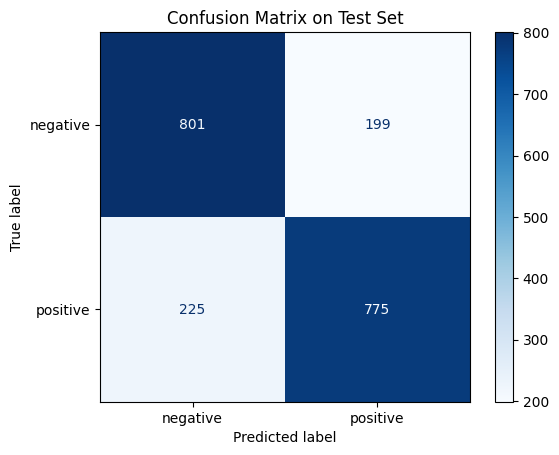

In [17]:
clf = LogisticRegression(max_iter=2000, random_state=SEED)
clf.fit(X_train, y_train)

train_pred = clf.predict(X_train)
val_pred   = clf.predict(X_val)
test_pred  = clf.predict(X_test)

print("Training Accuracy   :", round(accuracy_score(y_train, train_pred), 4))
print("Validation Accuracy :", round(accuracy_score(y_val, val_pred), 4))
print("Test Accuracy       :", round(accuracy_score(y_test, test_pred), 4))

print("\nClassification Report (Test):")
print(classification_report(y_test, test_pred, target_names=["negative", "positive"]))

cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "positive"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix on Test Set")
plt.show()


### C5. 5 correctly classified reviews and 5 incorrectly classified reviews

In [18]:
test_probs = clf.predict_proba(X_test)[:, 1]
test_df = test_df.copy()
test_df["pred_label"] = test_pred
test_df["pred_sentiment"] = test_df["pred_label"].map({0: "negative", 1: "positive"})
test_df["confidence"] = np.where(test_df["pred_label"] == 1, test_probs, 1 - test_probs)
test_df["correct"] = test_df["label"] == test_df["pred_label"]

def guess_failure_reason(text):
    text_lower = text.lower()
    if "not" in text_lower or "never" in text_lower or "hardly" in text_lower:
        return "Possible negation/context failure."
    if "but" in text_lower or "although" in text_lower or "however" in text_lower:
        return "Mixed sentiment: the review may contain both positive and negative cues."
    if "!" in text_lower or "?" in text_lower:
        return "Strong emphasis or tone may not be captured by average embeddings."
    if "worst" in text_lower and "best" in text_lower:
        return "Conflicting strong sentiment words may confuse the model."
    return "Likely a subtle context, sarcasm, or long-range meaning failure."

print("5 Correctly Classified Reviews\n" + "=" * 80)
correct_examples = test_df[test_df["correct"]].sort_values("confidence", ascending=False).head(5)

for _, row in correct_examples.iterrows():
    short_review = row["review"][:350].replace("\n", " ")
    print(f"True: {row['sentiment']:<8} | Predicted: {row['pred_sentiment']:<8} | Confidence: {row['confidence']:.3f}")
    print("Review:", short_review + ("..." if len(row["review"]) > 350 else ""))
    print()

print("\n5 Incorrectly Classified Reviews\n" + "=" * 80)
incorrect_examples = test_df[~test_df["correct"]].sort_values("confidence", ascending=False).head(5)

for _, row in incorrect_examples.iterrows():
    short_review = row["review"][:350].replace("\n", " ")
    print(f"True: {row['sentiment']:<8} | Predicted: {row['pred_sentiment']:<8} | Confidence: {row['confidence']:.3f}")
    print("Review:", short_review + ("..." if len(row["review"]) > 350 else ""))
    print("Why it may have failed:", guess_failure_reason(row["review"]))
    print()


5 Correctly Classified Reviews
True: positive | Predicted: positive | Confidence: 1.000
Review: A surprisingly beautiful movie. Beautifully conceived, beautifully directed, beautifully acted, beautifully acted and most beautifully photographed.....the cinematography is nothing short of splendid. It is a war movie but is epic in it's scope and blends romance, tragedy and comedy into a story that is as harrowing as it is provoking.

True: positive | Predicted: positive | Confidence: 0.999
Review: Its the best movie I have seen in 2000, it has the beautiful and talented Natalie Portman in it. It has a great storyline, cast and soundtrack. I enjoyed it very much. 10 out of 10

True: positive | Predicted: positive | Confidence: 0.998
Review: "Boogie Nights" is a masterpiece it tells a great story with flair an great direction from a very talented director. This film features a cast which turn in outstanding performances. Though the subject matter is very controversial but it is handled with

---
## Part D: (Code + Short Writing) Stress Test the Model: Where Order and Context Matter

### D1. Contrast set of 12 examples

In [19]:
contrast_sentences = [
    # negation
    "The movie was good.",
    "The movie was not good.",
    "I did not enjoy this film.",
    "I never hated the acting.",
    # word order
    "Dog bites man.",
    "Man bites dog.",
    "Flights from Astana to Almaty are cheap.",
    "Flights from Almaty to Astana are cheap.",
    # ambiguity / word sense
    "He went to the bank to deposit money.",
    "He sat by the river bank.",
    # translation / bilingual inspired
    "Translate this book.",
    "Book this flight.",
    # own choice
    "This movie is so bad that it is good.",
    "I hardly liked it."
]

def predict_sentence(sentence):
    tokens = preprocess_text(sentence)
    vec = get_mean_vector(tokens).reshape(1, -1)
    prob_pos = clf.predict_proba(vec)[0, 1]
    pred = "positive" if prob_pos >= 0.5 else "negative"
    return tokens, pred, prob_pos

rows = []
for sent in contrast_sentences:
    tokens, pred, prob_pos = predict_sentence(sent)
    rows.append({
        "sentence": sent,
        "tokens": tokens,
        "predicted_label": pred,
        "positive_probability": round(float(prob_pos), 4)
    })

contrast_df = pd.DataFrame(rows)
contrast_df


,sentence,tokens,predicted_label,positive_probability
0,The movie was good.,"[movie, good]",negative,0.4705
1,The movie was not good.,"[movie, not, good]",negative,0.2107
2,I did not enjoy this film.,"[not, enjoy, film]",positive,0.9893
3,I never hated the acting.,"[never, hated, acting]",negative,0.0125
4,Dog bites man.,"[dog, bites, man]",positive,0.6086
5,Man bites dog.,"[man, bites, dog]",positive,0.6086
6,Flights from Astana to Almaty are cheap.,"[flights, astana, almaty, cheap]",negative,0.0044
7,Flights from Almaty to Astana are cheap.,"[flights, almaty, astana, cheap]",negative,0.0044
8,He went to the bank to deposit money.,"[he, went, bank, deposit, money]",positive,0.7722
9,He sat by the river bank.,"[he, sat, river, bank]",positive,0.9363


### D2. Analyze failures

In [20]:
print("PART D2: 4 Important Failure Cases\n")

print("1. Negation failure")
print("   Example: 'The movie was good.' vs 'The movie was not good.'")
print("   Problem: the word 'good' can dominate the sentence vector, while negation is only weakly represented.")
print()

print("2. Word-order failure")
print("   Example: 'Dog bites man.' vs 'Man bites dog.'")
print("   Problem: both sentences contain the same words, so their average embedding is the same.")
print()

print("3. Polysemy / ambiguity")
print("   Example: 'He went to the bank to deposit money.' vs 'He sat by the river bank.'")
print("   Problem: the word 'bank' has one static vector, even though its meaning changes with context.")
print()

print("4. Command / noun ambiguity")
print("   Example: 'Translate this book.' vs 'Book this flight.'")
print("   Problem: the word 'book' can be a noun or a verb, but a static embedding does not fully resolve that difference.")
print()


PART D2: 4 Important Failure Cases

1. Negation failure
   Example: 'The movie was good.' vs 'The movie was not good.'
   Problem: the word 'good' can dominate the sentence vector, while negation is only weakly represented.

2. Word-order failure
   Example: 'Dog bites man.' vs 'Man bites dog.'
   Problem: both sentences contain the same words, so their average embedding is the same.

3. Polysemy / ambiguity
   Example: 'He went to the bank to deposit money.' vs 'He sat by the river bank.'
   Problem: the word 'bank' has one static vector, even though its meaning changes with context.

4. Command / noun ambiguity
   Example: 'Translate this book.' vs 'Book this flight.'
   Problem: the word 'book' can be a noun or a verb, but a static embedding does not fully resolve that difference.



### D3. Bridge to RNNs

Average embeddings lose order information because addition and averaging do not preserve token position.  
Static vectors also struggle with polysemy because a word such as **bank** usually has one fixed representation, even when its meaning changes by context.  
A sequence model such as an RNN processes tokens one by one and keeps a **hidden state**.  
That hidden state can remember what came before: negation, earlier entities, sentence direction, or the current meaning of an ambiguous word.  
This is exactly the type of information that a bag-of-embeddings model cannot store.


---
## Part E: (Code + Short Writing) Translation Mini-Track

In [21]:
pairs = [
    ("good morning", "қайырлы таң"),
    ("good night", "қайырлы түн"),
    ("hello", "сәлем"),
    ("goodbye", "сау бол"),
    ("thank you", "рақмет"),
    ("you are welcome", "оқасы жоқ"),
    ("please", "өтінемін"),
    ("sorry", "кешіріңіз"),
    ("yes", "иә"),
    ("no", "жоқ"),
    ("how are you", "қалыңыз қалай"),
    ("i am fine", "мен жақсымын"),
    ("what is your name", "атыңыз кім"),
    ("my name is", "менің атым"),
    ("where is the station", "вокзал қайда"),
    ("where is the airport", "әуежай қайда"),
    ("where is the hotel", "қонақүй қайда"),
    ("where is the bus stop", "аялдама қайда"),
    ("i need help", "маған көмек керек"),
    ("call the doctor", "дәрігер шақырыңыз"),
    ("i am lost", "мен адасып қалдым"),
    ("how much is this", "бұл қанша тұрады"),
    ("too expensive", "тым қымбат"),
    ("cheap ticket", "арзан билет"),
    ("book a ticket", "билет бронда"),
    ("buy a ticket", "билет сатып ал"),
    ("open the door", "есікті аш"),
    ("close the window", "терезені жап"),
    ("turn on the light", "жарықты жақ"),
    ("turn off the light", "жарықты өшір"),
    ("i love this movie", "маған бұл фильм ұнайды"),
    ("this movie is bad", "бұл фильм жаман"),
    ("this movie is good", "бұл фильм жақсы"),
    ("not good", "жақсы емес"),
    ("very good", "өте жақсы"),
    ("i am hungry", "менің қарным аш"),
    ("i am tired", "мен шаршадым"),
    ("i am ready", "мен дайынмын"),
    ("let us go", "жүрейік"),
    ("come here", "мұнда кел"),
    ("sit down", "отыр"),
    ("stand up", "тұр"),
    ("speak slowly", "баяу сөйлеңіз"),
    ("repeat please", "қайта айтыңызшы"),
    ("translate this", "мұны аударыңыз"),
    ("write your name", "атыңызды жазыңыз"),
    ("read the text", "мәтінді оқы"),
    ("from almaty to astana", "алматыдан астанаға"),
    ("from astana to almaty", "астанадан алматыға"),
    ("one tea please", "бір шай беріңізші"),
    ("one coffee please", "бір кофе беріңізші"),
    ("water please", "су беріңізші"),
    ("i do not understand", "мен түсінбеймін"),
    ("do you understand", "сіз түсінесіз бе"),
    ("help me please", "маған көмектесіңізші"),
    ("where are you", "қайдасыз"),
    ("i am at home", "мен үйдемін"),
    ("i am at school", "мен мектептемін"),
    ("today is cold", "бүгін суық"),
    ("today is warm", "бүгін жылы")
]

pairs_df = pd.DataFrame(pairs, columns=["english", "kazakh"])
print("Total phrase pairs:", len(pairs_df))
pairs_df.head(10)


Total phrase pairs: 60


,english,kazakh
0,good morning,қайырлы таң
1,good night,қайырлы түн
2,hello,сәлем
3,goodbye,сау бол
4,thank you,рақмет
5,you are welcome,оқасы жоқ
6,please,өтінемін
7,sorry,кешіріңіз
8,yes,иә
9,no,жоқ


Example after adding special tokens:
Source: ['<SOS>', 'good', 'morning', '<EOS>']
Target: ['<SOS>', 'қайырлы', 'таң', '<EOS>']


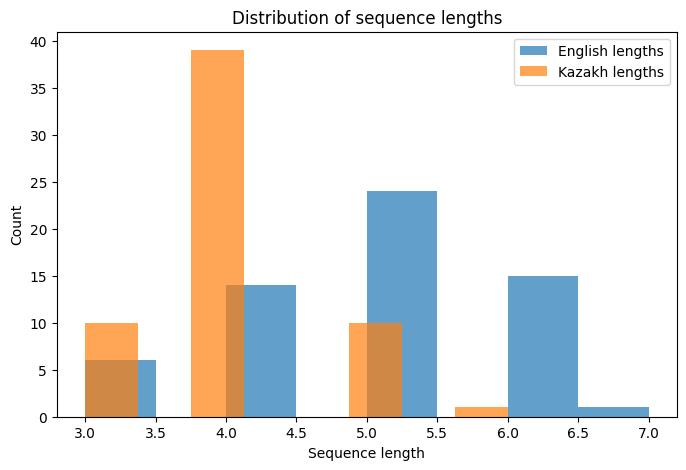

Average source length: 4.85
Average target length: 4.03


In [22]:
src_tokens = []
tgt_tokens = []

for src, tgt in pairs:
    src_seq = ["<SOS>"] + src.lower().split() + ["<EOS>"]
    tgt_seq = ["<SOS>"] + tgt.lower().split() + ["<EOS>"]
    src_tokens.append(src_seq)
    tgt_tokens.append(tgt_seq)

print("Example after adding special tokens:")
print("Source:", src_tokens[0])
print("Target:", tgt_tokens[0])

src_lens = [len(x) for x in src_tokens]
tgt_lens = [len(x) for x in tgt_tokens]

plt.figure(figsize=(8, 5))
plt.hist(src_lens, bins=8, alpha=0.7, label="English lengths")
plt.hist(tgt_lens, bins=8, alpha=0.7, label="Kazakh lengths")
plt.xlabel("Sequence length")
plt.ylabel("Count")
plt.title("Distribution of sequence lengths")
plt.legend()
plt.show()

print("Average source length:", round(np.mean(src_lens), 2))
print("Average target length:", round(np.mean(tgt_lens), 2))


In [23]:
max_len = max(max(src_lens), max(tgt_lens))

def pad_sequence(seq, max_len):
    return seq + ["<PAD>"] * (max_len - len(seq))

padded_src = [pad_sequence(seq, max_len) for seq in src_tokens]
padded_tgt = [pad_sequence(seq, max_len) for seq in tgt_tokens]

print("One padded batch example (first 5 source sequences):\n")
for i in range(5):
    print(f"{i+1}.", padded_src[i])

print("\nWhy padding is needed:")
print("Neural networks usually process batches with the same tensor shape.")
print("Sentences have different lengths, so we pad shorter ones with <PAD> to make them equal in length.")
print()
print("Why averaging source-word vectors is not enough for translation:")
print("A single average vector loses word order and cannot generate the target sentence token by token.")
print("Translation needs a model that remembers sequence order and produces output step by step.")


One padded batch example (first 5 source sequences):

1. ['<SOS>', 'good', 'morning', '<EOS>', '<PAD>', '<PAD>', '<PAD>']
2. ['<SOS>', 'good', 'night', '<EOS>', '<PAD>', '<PAD>', '<PAD>']
3. ['<SOS>', 'hello', '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']
4. ['<SOS>', 'goodbye', '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']
5. ['<SOS>', 'thank', 'you', '<EOS>', '<PAD>', '<PAD>', '<PAD>']

Why padding is needed:
Neural networks usually process batches with the same tensor shape.
Sentences have different lengths, so we pad shorter ones with <PAD> to make them equal in length.

Why averaging source-word vectors is not enough for translation:
A single average vector loses word order and cannot generate the target sentence token by token.
Translation needs a model that remembers sequence order and produces output step by step.


### Part E short explanation

Translation is a sequence-to-sequence task because the source sentence and the target sentence are both ordered token sequences.  
The model must know not only which words appear, but also in what order they appear and how they align across languages.  
Averaging source embeddings produces only one fixed vector and cannot decide which target word should come first, second, or last.  
That is why translation naturally motivates encoder-decoder models and recurrent architectures.


---
## Part F: (Written Answers) Follow-Up Questions

### General Questions

**1. What is the difference between a token, a type, and a vocabulary?**  
A token is one occurrence of a word or symbol in text. A type is a unique token form. A vocabulary is the full set of unique types used by the model or dataset.

**2. Why can pretrained embeddings help when the dataset is not very large?**  
They already contain semantic information learned from large corpora, so the model starts with useful word representations instead of learning everything from scratch.

**3. Why is average pooling over word vectors order-invariant?**  
Because averaging does not depend on position. The same set of word vectors gives the same average no matter how the words are ordered.

**4. Give one example where static embeddings are useful and one where they are not enough.**  
They are useful for simple sentiment classification baselines or topic classification. They are not enough for machine translation, sarcasm detection, or tasks where order and context are crucial.

**5. What is the difference between a word embedding and a sentence embedding?**  
A word embedding represents one word as a vector. A sentence embedding represents the whole sentence as one vector, often by combining the vectors of its words.

**6. Why can the word `bank` cause trouble for static embeddings?**  
Because `bank` can mean a financial institution or the side of a river. A static embedding usually gives it one fixed vector, even though the meaning changes.

**7. If two sentences contain the same words in a different order, what will happen to a plain average embedding? Why is that a problem?**  
They will get the same average vector. This is a problem because the sentences may have very different meanings.

**8. What would you want the hidden state of an RNN to remember while reading a sentence?**  
I would want it to remember the previous words, negation, key entities, the current topic, and context needed to interpret later words.


### Translation Mini-Track Questions

**9. Why do sequence-to-sequence models need `<SOS>` and `<EOS>` tokens?**  
`<SOS>` tells the decoder where to start generating. `<EOS>` tells the model where the sentence ends.

**10. Why do source and target sentences usually need padding in batches?**  
Because sentences have different lengths, but tensors in a batch need the same shape for efficient computation.

**11. Why is translation a sequence-to-sequence problem rather than a simple classification problem?**  
Because the output is not one label. The output is a full ordered sentence that must be generated token by token.


## Overall Conclusion

This assignment showed that **mean pooling over pretrained word embeddings** can be a strong and simple baseline.  
It works reasonably well for sentiment classification because the average vector often captures general semantic information.  
However, the contrast-set examples clearly show its weaknesses: it loses **word order**, handles **negation** poorly, and struggles with **polysemy** and **context**.  
The translation mini-track made the limitation even more obvious, because translation requires preserving sequence structure and generating output step by step.  
For these reasons, sequence models such as **RNNs**, **LSTMs**, and **GRUs** are a natural next step.
